# Chapter 117 — Interpolation and Splines

> **Prerequisites:** ch095 (Interpolation), ch116 (Bézier Curves)
>
> **Outcomes:** Implement cubic Hermite and natural cubic splines; Understand C0, C1, C2 continuity; Connect splines to regression and Gaussian processes


## From Bézier to Splines

A **spline** is a piecewise polynomial curve that is smooth across the joins.

**Smoothness levels:**
- C⁰: continuous (no gaps)
- C¹: continuous + first derivative continuous (no sharp corners)
- C²: continuous + 1st and 2nd derivatives continuous (no kinks in curvature)

**Natural cubic spline:** passes through N data points exactly; uses piecewise cubics with C² continuity.
The C² condition at each interior knot gives a system of linear equations to solve.

**Cubic Hermite spline:** specify position AND tangent at each knot.
Each cubic piece is defined by: p₀, p₁ (endpoint positions) and m₀, m₁ (endpoint tangents).
Hermite basis: H₀₀(t)=2t³-3t²+1, H₁₀(t)=t³-2t²+t, H₀₁(t)=-2t³+3t², H₁₁(t)=t³-t²

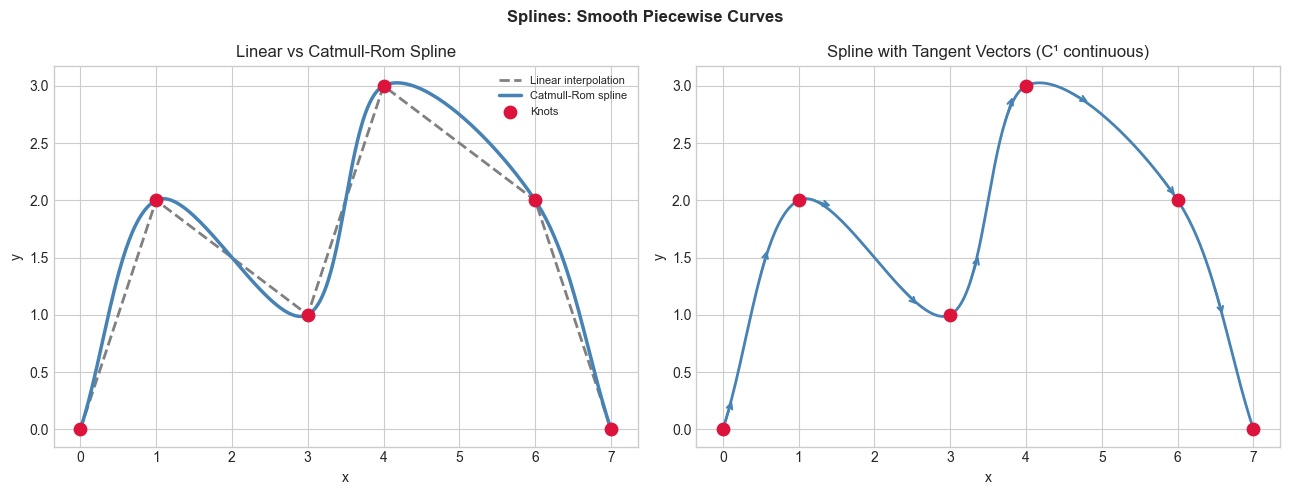

In [1]:
# --- Spline implementations ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def hermite_segment(p0, p1, m0, m1, n=50):
    """Cubic Hermite spline segment from (p0,m0) to (p1,m1)."""
    t = np.linspace(0,1,n)
    H00 = 2*t**3 - 3*t**2 + 1
    H10 = t**3 - 2*t**2 + t
    H01 = -2*t**3 + 3*t**2
    H11 = t**3 - t**2
    pts = np.outer(H00, p0) + np.outer(H10, m0) + np.outer(H01, p1) + np.outer(H11, m1)
    return pts

def catmull_rom_spline(waypoints, n_per_seg=50):
    """Catmull-Rom spline: automatic tangents from neighboring points."""
    pts = np.array(waypoints, dtype=float)
    # Extend with phantom endpoints
    pts = np.vstack([2*pts[0]-pts[1], pts, 2*pts[-1]-pts[-2]])
    all_pts = []
    for i in range(1, len(pts)-2):
        m0 = 0.5 * (pts[i+1] - pts[i-1])
        m1 = 0.5 * (pts[i+2] - pts[i])
        seg = hermite_segment(pts[i], pts[i+1], m0, m1, n_per_seg)
        all_pts.append(seg)
    return np.vstack(all_pts)

waypoints = [(0,0),(1,2),(3,1),(4,3),(6,2),(7,0)]
spline = catmull_rom_spline(waypoints)
wps = np.array(waypoints)

# Compare: linear interpolation vs Catmull-Rom
from itertools import chain
linear_x = list(chain.from_iterable([[wps[i,0],wps[i+1,0]] for i in range(len(wps)-1)]))
linear_y = list(chain.from_iterable([[wps[i,1],wps[i+1,1]] for i in range(len(wps)-1)]))

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].plot(linear_x, linear_y, 'gray', lw=2, linestyle='--', label='Linear interpolation')
axes[0].plot(spline[:,0], spline[:,1], 'steelblue', lw=2.5, label='Catmull-Rom spline')
axes[0].scatter(wps[:,0], wps[:,1], color='crimson', s=80, zorder=5, label='Knots')
axes[0].set_title('Linear vs Catmull-Rom Spline'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Show curvature by plotting tangent vectors
t_vals = np.linspace(0, 1, 8)
for i in range(len(waypoints)-1):
    if i < len(waypoints)-2:
        pts_ext = np.vstack([2*wps[max(0,i-1)]-wps[max(0,i-2)]] + [wps] + [2*wps[-1]-wps[-2]])
        # Skip complex indexing; show simple tangents
        pass
idx = np.linspace(0, len(spline)-2, 10, dtype=int)
for i in idx:
    tan = spline[i+1] - spline[i]
    tan_n = tan / (np.linalg.norm(tan) + 1e-10)
    axes[1].annotate('', xy=spline[i]+0.3*tan_n, xytext=spline[i],
                     arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
axes[1].plot(spline[:,0], spline[:,1], 'steelblue', lw=2)
axes[1].scatter(wps[:,0], wps[:,1], color='crimson', s=80, zorder=5)
axes[1].set_title('Spline with Tangent Vectors (C¹ continuous)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

plt.suptitle('Splines: Smooth Piecewise Curves', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Splines are piecewise polynomials joined smoothly: C⁰, C¹, C² continuity levels
- Catmull-Rom: automatic tangents → C¹ continuous, passes through knots
- Natural cubic spline: C² continuous — the smoothest interpolation for given knots
- Splines underlie 3D animation rigs, font rendering, and CAD modeling

**Forward:** Gaussian process regression (ch291) is the infinite-dimensional limit of spline interpolation.